In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [68]:
# AnalystLab Africa — Week 1 Data Analysis
## Task 1: Dataset Understanding
### Dataset 1 — E-commerce Transactions

In [69]:
# Load the e-commerce dataset
# encoding='latin1' handles special characters in the file
df_ecom = pd.read_csv("OnlineRetail.csv", encoding='latin1')

# Show the first 5 rows
df_ecom.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [70]:
# How many rows and columns does this dataset have?
print("Shape of dataset:", df_ecom.shape)

rows, cols = df_ecom.shape
print(f"This dataset has {rows} rows and {cols} columns")

Shape of dataset: (541909, 8)
This dataset has 541909 rows and 8 columns


In [71]:
# What data type is each column?
# object = text, int64 = whole number, float64 = decimal number
print("Data types of all columns:")
print(df_ecom.dtypes)

Data types of all columns:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [72]:
# Separate numerical columns from categorical (text) columns
numerical_cols = df_ecom.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_ecom.select_dtypes(include=['str']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['Quantity', 'UnitPrice', 'CustomerID']
Categorical columns: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [73]:
# Check possible unique identifiers
# These are columns where each value is unique — like a primary key
print("Unique InvoiceNo values:", df_ecom['InvoiceNo'].nunique())
print("Unique CustomerID values:", df_ecom['CustomerID'].nunique())
print("Unique StockCode values:", df_ecom['StockCode'].nunique())

Unique InvoiceNo values: 25900
Unique CustomerID values: 4372
Unique StockCode values: 4070


### What does this dataset contain?

This dataset contains online retail transactions from a UK-based store between 2010 and 2011.
Each row represents one product line from a customer invoice.

- **InvoiceNo** — unique transaction ID
- **StockCode** — unique product code
- **Description** — product name
- **Quantity** — number of units bought
- **InvoiceDate** — date and time of purchase
- **UnitPrice** — price per unit
- **CustomerID** — unique customer identifier
- **Country** — country where the customer is based

Possible primary key: InvoiceNo + StockCode combined


### Dataset 2 — Netflix Movies & TV Shows

In [74]:
# Load the Netflix dataset
df_netflix = pd.read_csv("netflix_titles.csv")

# Show the first 5 rows
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [75]:
# Numerical and categorical columns
numerical_cols_n = df_netflix.select_dtypes(include=['number']).columns.tolist()
categorical_cols_n = df_netflix.select_dtypes(include=['str']).columns.tolist()

print("Numerical columns:", numerical_cols_n)
print("Categorical columns:", categorical_cols_n)

Numerical columns: ['release_year']
Categorical columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [76]:
# Unique identifiers
print("Unique show_id values:", df_netflix['show_id'].nunique())
print("Unique titles:", df_netflix['title'].nunique())

Unique show_id values: 8807
Unique titles: 8807


### What does this dataset contain?

This dataset contains Netflix content information up to 2021.
Each row represents one movie or TV show available on Netflix.

- **show_id** — unique ID for each title
- **type** — Movie or TV Show
- **title** — name of the content
- **director** — who directed it
- **cast** — actors involved
- **country** — country where it was produced
- **date_added** — when it was added to Netflix
- **release_year** — year it was originally released
- **rating** — content rating (PG, TV-MA, etc.)
- **duration** — length in minutes or seasons
- **listed_in** — genre categories
- **description** — short summary

Possible primary key: show_id

## Task 2: Data Cleaning
### Dataset 1 — E-commerce Transactions

In [77]:
# Record how many rows we started with
# We'll compare this at the end to see how much data was cleaned
original_count = len(df_ecom)
print(f"Original number of rows: {original_count}")

Original number of rows: 541909


In [78]:
# STEP 1: CHECK FOR MISSING VALUES
# isnull() marks every empty cell as True
# .sum() counts how many empty cells per column
# We also calculate the percentage so we know how serious each one is

missing_count = df_ecom.isnull().sum()
missing_percent = (missing_count / len(df_ecom)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent.round(2)
})

print(missing_summary)

             Missing Count  Percentage (%)
InvoiceNo                0            0.00
StockCode                0            0.00
Description           1454            0.27
Quantity                 0            0.00
InvoiceDate              0            0.00
UnitPrice                0            0.00
CustomerID          135080           24.93
Country                  0            0.00


In [79]:
# STEP 2: HANDLE MISSING VALUES

# CustomerID — drop rows where it's missing
df_ecom.dropna(subset=['CustomerID'], inplace=True)
print(f"Rows after dropping missing CustomerID: {len(df_ecom)}")

# Description — fill missing with 'Unknown' (updated syntax for pandas 3)
df_ecom = df_ecom.assign(Description=df_ecom['Description'].fillna('Unknown'))

# Confirm no missing values remain
print("\nMissing values after handling:")
print(df_ecom.isnull().sum())

Rows after dropping missing CustomerID: 406829

Missing values after handling:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [80]:
# STEP 3: CHECK FOR DUPLICATE ROWS
# A duplicate means every single column value matches another row exactly
duplicate_count = df_ecom.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Remove duplicates - keeps the first occurrence, deletes the rest
df_ecom = df_ecom.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_ecom)}")
print(f"Total duplicates removed: {duplicate_count}")

Number of duplicate rows found: 5225
Rows after removing duplicates: 401604
Total duplicates removed: 5225


**Duplicate Records — E-commerce:**
Found 5,225 fully duplicate rows (same invoice, product, quantity, date, price, customer, and country).
These were removed as they represent the same transaction recorded twice — likely a data entry or export error.

### Standardization — E-commerce

In [81]:
# STEP 4A: STANDARDIZE COLUMN NAMES
# Convert all column names to lowercase with underscores instead of spaces
# This makes them consistent and easier to type

df_ecom.columns = df_ecom.columns.str.strip().str.lower().str.replace(' ', '_')

print("New column names:", df_ecom.columns.tolist())

New column names: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']


In [82]:
# STEP 4B: STANDARDIZE DATE FORMAT
# Right now invoicedate is stored as text
# pd.to_datetime() converts it into a proper date/time format
# This lets us do date math, sort by date, and extract month/year later

df_ecom['invoicedate'] = pd.to_datetime(df_ecom['invoicedate'])

print("New data type of invoicedate:", df_ecom['invoicedate'].dtype)
print("\nSample dates:")
print(df_ecom['invoicedate'].head())

New data type of invoicedate: datetime64[us]

Sample dates:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: invoicedate, dtype: datetime64[us]


In [83]:
# STEP 4C: STANDARDIZE TEXT FORMATTING
# Strip extra spaces and apply consistent casing (Title Case) to text columns
# This prevents "uk" and "UK" and "Uk " being treated as different values

df_ecom['description'] = df_ecom['description'].str.strip().str.title()
df_ecom['country'] = df_ecom['country'].str.strip().str.title()

print(df_ecom[['description', 'country']].head())

                           description         country
0   White Hanging Heart T-Light Holder  United Kingdom
1                  White Metal Lantern  United Kingdom
2       Cream Cupid Hearts Coat Hanger  United Kingdom
3  Knitted Union Flag Hot Water Bottle  United Kingdom
4       Red Woolly Hottie White Heart.  United Kingdom


In [84]:
# STEP 4D: FIX CUSTOMERID DATA TYPE
# CustomerID is currently a float (e.g. 17850.0) but it's an identifier, not a number to do math with
# Convert it to a whole number (integer)

df_ecom['customerid'] = df_ecom['customerid'].astype(int)

print("New data type of customerid:", df_ecom['customerid'].dtype)
print(df_ecom['customerid'].head())

New data type of customerid: int64
0    17850
1    17850
2    17850
3    17850
4    17850
Name: customerid, dtype: int64


### Data Validation — E-commerce

In [85]:
# STEP 5A: CHECK FOR INVALID QUANTITY VALUES
# A quantity of 0 or negative doesn't represent a real sale
# Negative quantities usually mean a product return

invalid_qty = (df_ecom['quantity'] <= 0).sum()
print(f"Rows with Quantity <= 0: {invalid_qty}")

# Remove them — we're focusing on actual sales transactions
df_ecom = df_ecom[df_ecom['quantity'] > 0]
print(f"Rows remaining: {len(df_ecom)}")

Rows with Quantity <= 0: 8872
Rows remaining: 392732


In [86]:
# STEP 5B: CHECK FOR INVALID UNIT PRICE VALUES
# A price of 0 or negative is not a valid sale

invalid_price = (df_ecom['unitprice'] <= 0).sum()
print(f"Rows with UnitPrice <= 0: {invalid_price}")

# Remove them
df_ecom = df_ecom[df_ecom['unitprice'] > 0]
print(f"Rows remaining: {len(df_ecom)}")

Rows with UnitPrice <= 0: 40
Rows remaining: 392692


In [87]:
# STEP 5C: CHECK FOR CANCELLATION INVOICES
# Invoice numbers starting with 'C' represent CANCELLED orders, not actual sales
# Example: C536379 means invoice 536379 was cancelled

cancellations = df_ecom[df_ecom['invoiceno'].astype(str).str.startswith('C')]
print(f"Cancellation rows found: {len(cancellations)}")

# Remove them — they don't represent completed sales
df_ecom = df_ecom[~df_ecom['invoiceno'].astype(str).str.startswith('C')]
print(f"Rows remaining: {len(df_ecom)}")

Cancellation rows found: 0
Rows remaining: 392692


**Data Validation — E-commerce:**
- Removed 8,872 rows with Quantity ≤ 0 (returns/errors, not valid sales)
- Removed 40 rows with UnitPrice ≤ 0 (invalid pricing)
- Checked for cancellation invoices (starting with 'C') — found 0, since these were
  already captured by the negative quantity check above
- Final row count: 392,692 (down from original 541,909)

### Cleaning Summary — E-commerce

In [88]:
# CLEANING SUMMARY TABLE
cleaning_summary_ecom = pd.DataFrame({
    'Issue Found': [
        'Missing CustomerID (135,080 rows, 24.93%)',
        'Missing Description (1,454 rows, 0.27%)',
        'Duplicate Rows (5,225)',
        'Negative/Zero Quantity (8,872 rows)',
        'Negative/Zero Unit Price (40 rows)',
        'Cancellation Invoices',
        'Column Name Formatting',
        'Text Case Inconsistency',
        'Date Format',
        'CustomerID Data Type'
    ],
    'Action Taken': [
        'Rows dropped — unusable without customer identity',
        'Filled with "Unknown" — transaction data still valid',
        'Removed, kept first occurrence',
        'Rows dropped — not valid sales',
        'Rows dropped — not valid sales',
        'Checked — none found after quantity cleaning',
        'Converted to lowercase with underscores',
        'Applied Title Case to description and country',
        'Converted to datetime format',
        'Converted from float to integer'
    ]
})

print(cleaning_summary_ecom.to_string(index=False))

                              Issue Found                                         Action Taken
Missing CustomerID (135,080 rows, 24.93%)    Rows dropped — unusable without customer identity
  Missing Description (1,454 rows, 0.27%) Filled with "Unknown" — transaction data still valid
                   Duplicate Rows (5,225)                       Removed, kept first occurrence
      Negative/Zero Quantity (8,872 rows)                       Rows dropped — not valid sales
       Negative/Zero Unit Price (40 rows)                       Rows dropped — not valid sales
                    Cancellation Invoices         Checked — none found after quantity cleaning
                   Column Name Formatting              Converted to lowercase with underscores
                  Text Case Inconsistency        Applied Title Case to description and country
                              Date Format                         Converted to datetime format
                     CustomerID Data Type         

## Task 2: Data Cleaning (continued)
### Dataset 2 — Netflix Movies & TV Shows

In [89]:
# Record how many rows we started with
original_count_netflix = len(df_netflix)
print(f"Original number of rows: {original_count_netflix}")

Original number of rows: 8807


In [90]:
# STEP 1: CHECK FOR MISSING VALUES
missing_count_n = df_netflix.isnull().sum()
missing_percent_n = (missing_count_n / len(df_netflix)) * 100

missing_summary_n = pd.DataFrame({
    'Missing Count': missing_count_n,
    'Percentage (%)': missing_percent_n.round(2)
})

print(missing_summary_n)

              Missing Count  Percentage (%)
show_id                   0            0.00
type                      0            0.00
title                     0            0.00
director               2634           29.91
cast                    825            9.37
country                 831            9.44
date_added               10            0.11
release_year              0            0.00
rating                    4            0.05
duration                  3            0.03
listed_in                 0            0.00
description               0            0.00


In [91]:
# STEP 2: HANDLE MISSING VALUES

# director, cast, country — fill with 'Not Specified'
# Reason: These are descriptive fields. Dropping rows would lose a huge amount of data
# (especially director at ~30%). The content itself (title, type, genre) is still valid and useful.
df_netflix = df_netflix.assign(
    director=df_netflix['director'].fillna('Not Specified'),
    cast=df_netflix['cast'].fillna('Not Specified'),
    country=df_netflix['country'].fillna('Not Specified')
)

# rating and duration — fill with 'Not Rated' / 'Not Specified'
# Reason: Very small number of rows (under 0.1%), but dropping isn't necessary
# since other fields in these rows are still complete and useful
df_netflix = df_netflix.assign(
    rating=df_netflix['rating'].fillna('Not Rated'),
    duration=df_netflix['duration'].fillna('Not Specified')
)

# date_added — drop rows where it's missing
# Reason: Only 10 rows (0.11%). We need this column for trend analysis (Task 3),
# so a date is essential. Dropping 10 rows out of 8,807 has negligible impact.
df_netflix = df_netflix.dropna(subset=['date_added'])

print(f"Rows after handling missing values: {len(df_netflix)}")
print("\nMissing values remaining:")
print(df_netflix.isnull().sum())

Rows after handling missing values: 8797

Missing values remaining:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


**Missing Value Decisions — Netflix:**
- director (29.91%), cast (9.37%), country (9.44%): Filled with "Not Specified".
  These are descriptive fields, dropping would lose huge amounts of usable data
  about the title, type, genre, and rating.
- rating (0.05%), duration (0.03%): Filled with placeholders — negligible amount of data.
- date_added (0.11%): Dropped these 10 rows — date is required for trend analysis (Task 3)
  and removing 10 rows out of 8,807 has no meaningful impact.

In [92]:
# STEP 3: CHECK FOR DUPLICATE ROWS
duplicate_count_n = df_netflix.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count_n}")

# Remove duplicates
df_netflix = df_netflix.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_netflix)}")

Number of duplicate rows found: 0
Rows after removing duplicates: 8797


### Standardization — Netflix

In [93]:
# STEP 4A: STANDARDIZE COLUMN NAMES
df_netflix.columns = df_netflix.columns.str.strip().str.lower().str.replace(' ', '_')

print("Column names:", df_netflix.columns.tolist())

Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [94]:
# STEP 4B: STANDARDIZE DATE FORMAT
# date_added is currently text (e.g. "September 25, 2021")
# Convert it to proper datetime format

df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'].str.strip())

# Extract the year as its own column — we'll use this in Task 3 (content added by year)
df_netflix['year_added'] = df_netflix['date_added'].dt.year

print("New data type of date_added:", df_netflix['date_added'].dtype)
print("\nSample:")
print(df_netflix[['date_added', 'year_added']].head())

New data type of date_added: datetime64[us]

Sample:
  date_added  year_added
0 2021-09-25        2021
1 2021-09-24        2021
2 2021-09-24        2021
3 2021-09-24        2021
4 2021-09-24        2021


In [95]:
# STEP 4C: STANDARDIZE TEXT FORMATTING
# Strip extra spaces and apply consistent casing to text columns

df_netflix['country'] = df_netflix['country'].str.strip().str.title()
df_netflix['type'] = df_netflix['type'].str.strip().str.title()
df_netflix['rating'] = df_netflix['rating'].str.strip().str.upper()

print(df_netflix[['country', 'type', 'rating']].head())

         country     type rating
0  United States    Movie  PG-13
1   South Africa  Tv Show  TV-MA
2  Not Specified  Tv Show  TV-MA
3  Not Specified  Tv Show  TV-MA
4          India  Tv Show  TV-MA


### Data Validation — Netflix

In [96]:
# STEP 5A: VALIDATE THE 'type' COLUMN
# Should only contain 'Movie' and 'Tv Show' — check for anything unexpected

print("Unique values in 'type':", df_netflix['type'].unique())

Unique values in 'type': <StringArray>
['Movie', 'Tv Show']
Length: 2, dtype: str


In [97]:
# STEP 5B: VALIDATE THE 'rating' COLUMN
# Check for any unusual or invalid rating values
print("Unique values in 'rating':", df_netflix['rating'].unique())

Unique values in 'rating': <StringArray>
[    'PG-13',     'TV-MA',        'PG',     'TV-14',     'TV-PG',      'TV-Y',
     'TV-Y7',         'R',      'TV-G',         'G',     'NC-17',    '74 MIN',
    '84 MIN',    '66 MIN',        'NR', 'NOT RATED',  'TV-Y7-FV',        'UR']
Length: 18, dtype: str


In [98]:
# STEP 5C: FIX MISPLACED VALUES IN 'rating' COLUMN
# Some rows have a duration value (e.g. '74 min') sitting in the rating column
# This happened because of a column-shift error in the original data
# These rows are missing their actual duration value too

# Find the affected rows
misplaced = df_netflix[df_netflix['rating'].str.contains('MIN', na=False)]
print(f"Rows with duration value in 'rating' column: {len(misplaced)}")
print(misplaced[['title', 'rating', 'duration']])

Rows with duration value in 'rating' column: 3
                                     title  rating       duration
5541                       Louis C.K. 2017  74 MIN  Not Specified
5794                 Louis C.K.: Hilarious  84 MIN  Not Specified
5813  Louis C.K.: Live at the Comedy Store  66 MIN  Not Specified


In [99]:
# STEP 5D: FIX THE 3 MISPLACED ROWS
# For these 3 rows:
# - Move the value currently in 'rating' (e.g. '74 min') into 'duration'
# - Replace 'rating' with 'Not Rated' since the actual rating is unknown

# Get the index of the affected rows
misplaced_index = df_netflix[df_netflix['rating'].str.contains('MIN', na=False)].index

# Move the duration value over
df_netflix.loc[misplaced_index, 'duration'] = df_netflix.loc[misplaced_index, 'rating']

# Set rating to 'Not Rated'
df_netflix.loc[misplaced_index, 'rating'] = 'Not Rated'

# Confirm the fix
print(df_netflix.loc[misplaced_index, ['title', 'rating', 'duration']])

                                     title     rating duration
5541                       Louis C.K. 2017  Not Rated   74 MIN
5794                 Louis C.K.: Hilarious  Not Rated   84 MIN
5813  Louis C.K.: Live at the Comedy Store  Not Rated   66 MIN


In [100]:
# STEP 5E: VALIDATE release_year COLUMN
# Check for any unrealistic years (e.g. before 1900 or in the future)

print("Minimum release_year:", df_netflix['release_year'].min())
print("Maximum release_year:", df_netflix['release_year'].max())

Minimum release_year: 1925
Maximum release_year: 2021


**Data Validation — Netflix:**
- 'type' column validated — only contains "Movie" and "Tv Show", no invalid entries.
- 'rating' column had 3 rows with a duration value (e.g. "74 min") mistakenly placed in it,
  caused by a column-shift error in the original data. Fixed by moving the value into
  the 'duration' column and setting 'rating' to "Not Rated" for those rows.
- 'release_year' validated — ranges from 1925 to 2021, all realistic values.

### Cleaning Summary — Netflix

In [101]:
# CLEANING SUMMARY TABLE — NETFLIX
cleaning_summary_netflix = pd.DataFrame({
    'Issue Found': [
        'Missing director (2,634 rows, 29.91%)',
        'Missing cast (825 rows, 9.37%)',
        'Missing country (831 rows, 9.44%)',
        'Missing rating (4 rows)',
        'Missing duration (3 rows)',
        'Missing date_added (10 rows)',
        'Duplicate Rows',
        'Column Name Formatting',
        'Text Case Inconsistency',
        'Date Format',
        'Misplaced Values in Rating (3 rows)'
    ],
    'Action Taken': [
        'Filled with "Not Specified"',
        'Filled with "Not Specified"',
        'Filled with "Not Specified"',
        'Filled with "Not Rated"',
        'Filled with "Not Specified"',
        'Rows dropped — needed for trend analysis',
        'Checked — none found',
        'Converted to lowercase with underscores',
        'Applied Title Case (country, type) and Upper Case (rating)',
        'Converted date_added to datetime, extracted year_added',
        'Corrected — moved duration values, set rating to "Not Rated"'
    ]
})

print(cleaning_summary_netflix.to_string(index=False))

                          Issue Found                                                 Action Taken
Missing director (2,634 rows, 29.91%)                                  Filled with "Not Specified"
       Missing cast (825 rows, 9.37%)                                  Filled with "Not Specified"
    Missing country (831 rows, 9.44%)                                  Filled with "Not Specified"
              Missing rating (4 rows)                                      Filled with "Not Rated"
            Missing duration (3 rows)                                  Filled with "Not Specified"
         Missing date_added (10 rows)                     Rows dropped — needed for trend analysis
                       Duplicate Rows                                         Checked — none found
               Column Name Formatting                      Converted to lowercase with underscores
              Text Case Inconsistency   Applied Title Case (country, type) and Upper Case (rating)
          

## Task 3: Exploratory Data Analysis (EDA)
### Dataset 1 — E-commerce Transactions

In [102]:
# SUMMARY STATISTICS — Quantity and UnitPrice
# .describe() gives us count, mean, std, min, max, and percentiles all at once

print(df_ecom[['quantity', 'unitprice']].describe())

            quantity      unitprice
count  392692.000000  392692.000000
mean       13.119702       3.125914
std       180.492832      22.241836
min         1.000000       0.001000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000


In [103]:
# CREATE A REVENUE COLUMN
# Revenue = Quantity x UnitPrice for each transaction line
df_ecom['revenue'] = df_ecom['quantity'] * df_ecom['unitprice']

print(df_ecom[['quantity', 'unitprice', 'revenue']].head())

   quantity  unitprice  revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


### Analysis 1: Top 10 Best-Selling Products (by Quantity)

In [104]:
# Group by product description, sum the quantity sold, sort highest first
top_products = df_ecom.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        77916
World War 2 Gliders Asstd Designs     54319
Jumbo Bag Red Retrospot               46078
White Hanging Heart T-Light Holder    36706
Assorted Colour Bird Ornament         35263
Pack Of 72 Retrospot Cake Cases       33670
Popcorn Holder                        30919
Rabbit Night Light                    27153
Mini Paint Set Vintage                26076
Name: quantity, dtype: int64


### Analysis 2: Top 10 Revenue-Generating Countries

In [105]:
# Group by country, sum the revenue, sort highest first
top_countries = df_ecom.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_countries)

country
United Kingdom    7285024.644
Netherlands        285446.340
Eire               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64


### Analysis 3: Monthly Sales Trend

In [106]:
# Extract year-month from invoicedate, group by it, sum revenue
df_ecom['month'] = df_ecom['invoicedate'].dt.to_period('M')
monthly_sales = df_ecom.groupby('month')['revenue'].sum()
print(monthly_sales)

month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: revenue, dtype: float64


### Analysis 4: Top 10 Customers by Revenue

In [107]:
# Group by customer ID, sum revenue, sort highest first
top_customers = df_ecom.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customerid
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: revenue, dtype: float64


### Analysis 5: Most Frequently Purchased Products (by Number of Orders)

In [108]:
# Group by product, count how many separate invoices included it
most_purchased = df_ecom.groupby('description')['invoiceno'].nunique().sort_values(ascending=False).head(10)
print(most_purchased)

description
White Hanging Heart T-Light Holder    1971
Regency Cakestand 3 Tier              1703
Jumbo Bag Red Retrospot               1600
Party Bunting                         1379
Assorted Colour Bird Ornament         1375
Lunch Bag Red Retrospot               1288
Set Of 3 Cake Tins Pantry Design      1146
Postage                               1099
Lunch Bag  Black Skull.               1052
Pack Of 72 Retrospot Cake Cases       1029
Name: invoiceno, dtype: int64


### Analysis 6: Customer Purchasing Behavior — Average Order Value

In [109]:
# For each customer, calculate total revenue and number of unique invoices
customer_summary = df_ecom.groupby('customerid').agg(
    total_revenue=('revenue', 'sum'),
    total_orders=('invoiceno', 'nunique')
)

# Average order value = total revenue / number of orders
customer_summary['avg_order_value'] = customer_summary['total_revenue'] / customer_summary['total_orders']

print(customer_summary.sort_values('total_revenue', ascending=False).head(10))

            total_revenue  total_orders  avg_order_value
customerid                                              
14646           280206.02            73      3838.438630
18102           259657.30            60      4327.621667
17450           194390.79            46      4225.886739
16446           168472.50             2     84236.250000
14911           143711.17           201       714.980945
12415           124914.53            21      5948.310952
14156           117210.08            55      2131.092364
17511            91062.38            31      2937.496129
16029            80850.84            63      1283.346667
12346            77183.60             1     77183.600000


### Dataset 2 — Netflix Movies & TV Shows

In [110]:
# SUMMARY STATISTICS — release_year
# This is the only numerical column in this dataset
print(df_netflix[['release_year']].describe())

       release_year
count   8797.000000
mean    2014.183472
std        8.822191
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


### Analysis 1: Movies vs TV Shows Distribution

In [111]:
# Count how many Movies vs Tv Shows
type_distribution = df_netflix['type'].value_counts()
print(type_distribution)

type
Movie      6131
Tv Show    2666
Name: count, dtype: int64


### Analysis 2: Content Added by Year

In [112]:
# Count how many titles were added each year
content_by_year = df_netflix['year_added'].value_counts().sort_index()
print(content_by_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


### Analysis 3: Top 10 Content-Producing Countries

In [113]:
# Count titles per country
# Note: 'Not Specified' will likely appear high since we filled missing values with it
top_countries_netflix = df_netflix['country'].value_counts().head(10)
print(top_countries_netflix)

country
United States     2812
India              972
Not Specified      830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


### Analysis 4: Most Common Ratings

In [114]:
# Count how many titles have each rating
rating_counts = df_netflix['rating'].value_counts()
print(rating_counts)

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
NOT RATED       4
NC-17           3
Not Rated       3
UR              3
Name: count, dtype: int64


### Analysis 5: Most Common Genres

In [115]:
# The 'listed_in' column contains multiple genres separated by commas, e.g. "Dramas, International Movies"
# We split each row's genres into separate items, then count each genre individually

genres = df_netflix['listed_in'].str.split(', ').explode()
genre_counts = genres.value_counts().head(10)
print(genre_counts)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


### Analysis 6: Movies vs TV Shows Added Over Time

In [116]:
# Cross-tabulate year_added with type — shows how the Movie/TV Show split changed over the years
type_by_year = df_netflix.groupby(['year_added', 'type']).size().unstack()
print(type_by_year)

type         Movie  Tv Show
year_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         253.0    176.0
2017         839.0    349.0
2018        1237.0    412.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


In [117]:
# FIX: Consolidate inconsistent rating labels
# "NOT RATED" and "Not Rated" are the same thing with different casing
# (Our earlier .str.upper() should have caught this, but "Not Rated" was added AFTER that step
# when we fixed the misplaced duration values)

df_netflix['rating'] = df_netflix['rating'].replace({'Not Rated': 'NOT RATED'})

# Confirm
print(df_netflix['rating'].value_counts())

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
NOT RATED       7
TV-Y7-FV        6
NC-17           3
UR              3
Name: count, dtype: int64


**Additional Standardization Fix — Netflix:**
Discovered "Not Rated" (3 entries) and "NOT RATED" (4 entries) existed as separate values
due to a casing inconsistency introduced during the misplaced-rating fix in Task 2.
Consolidated both into "NOT RATED" for consistency.

## Task 4: Data Visualization
### Dataset 1 — E-commerce Transactions

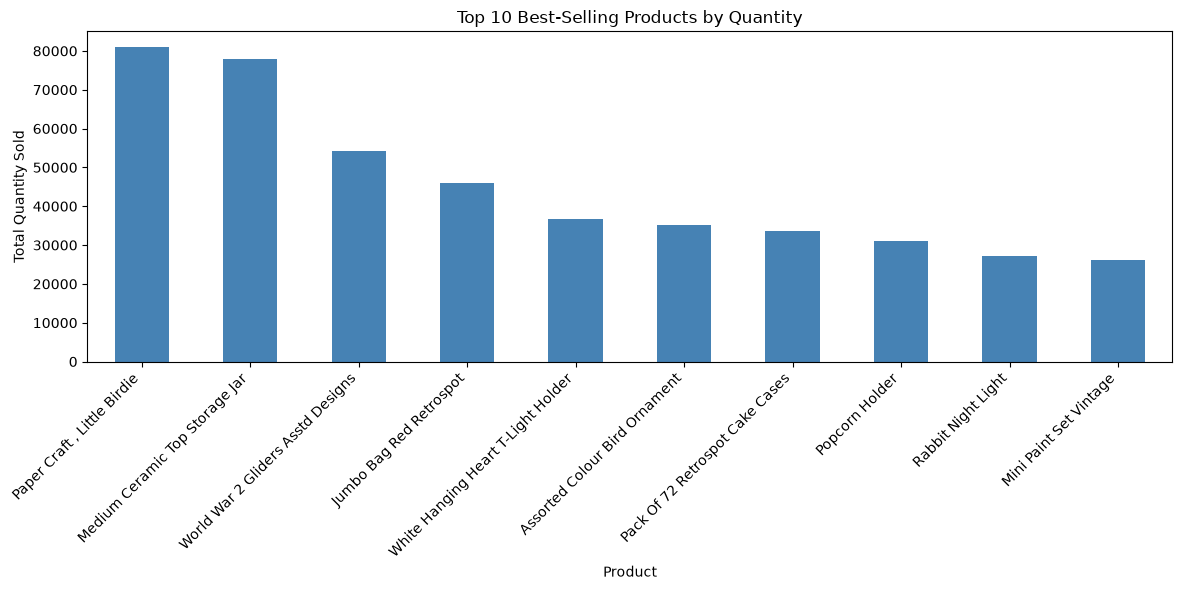

In [118]:
# CHART 1: Top 10 Best-Selling Products by Quantity
plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='steelblue')

plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** "Paper Craft, Little Birdie" and "Medium Ceramic Top Storage Jar" are the
two best-selling products by quantity, each selling over 75,000 units — significantly
ahead of other products.

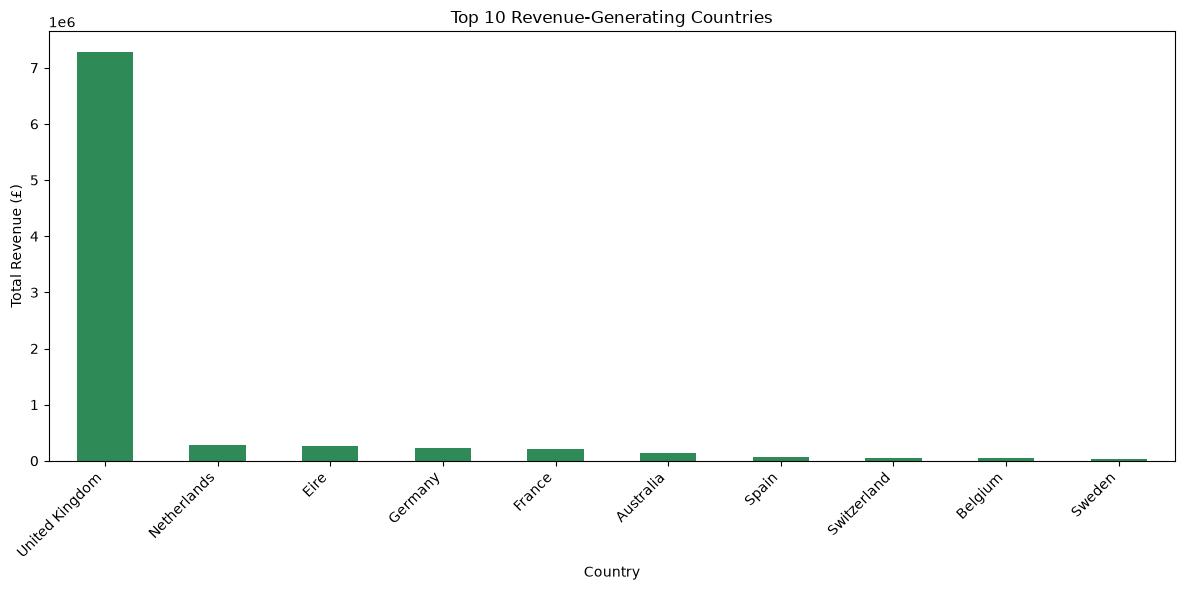

In [119]:
# CHART 2: Top 10 Countries by Revenue
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='seagreen')

plt.title('Top 10 Revenue-Generating Countries')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** The United Kingdom dominates revenue at over £7.2 million, dwarfing every
other country. The Netherlands, Eire (Ireland), Germany, and France follow far behind,
each under £300,000.

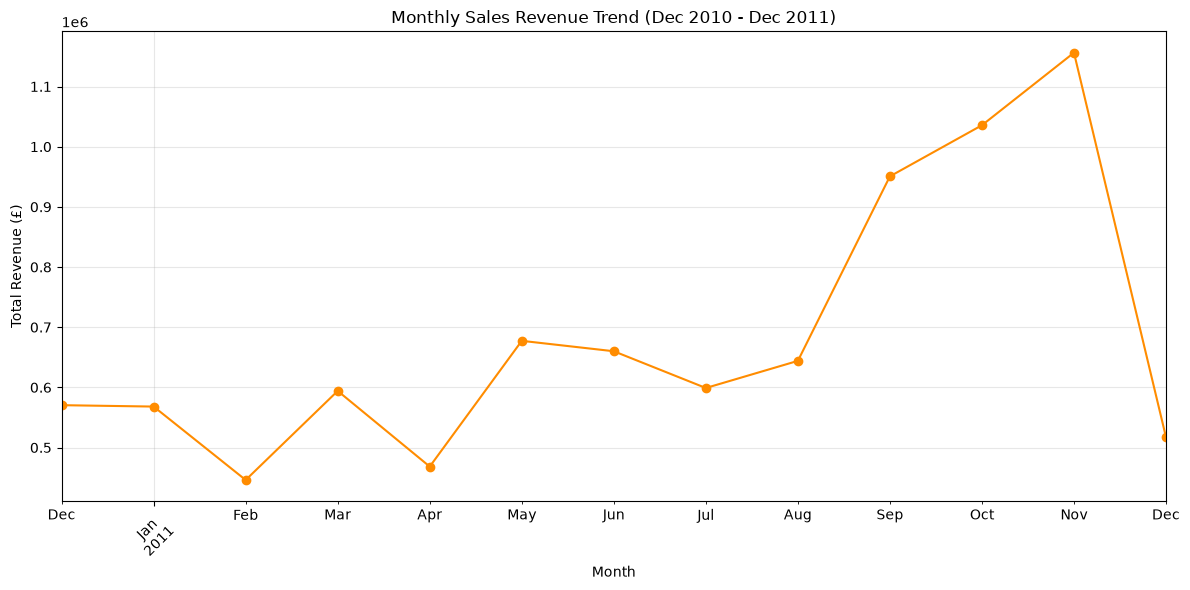

In [120]:
# CHART 3: Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='darkorange')

plt.title('Monthly Sales Revenue Trend (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Finding:** Revenue shows a clear upward trend from August to November 2011, peaking in
November at over £1.15 million — likely driven by pre-holiday shopping. December 2011
appears lower because the dataset ends mid-month, not because sales actually dropped.

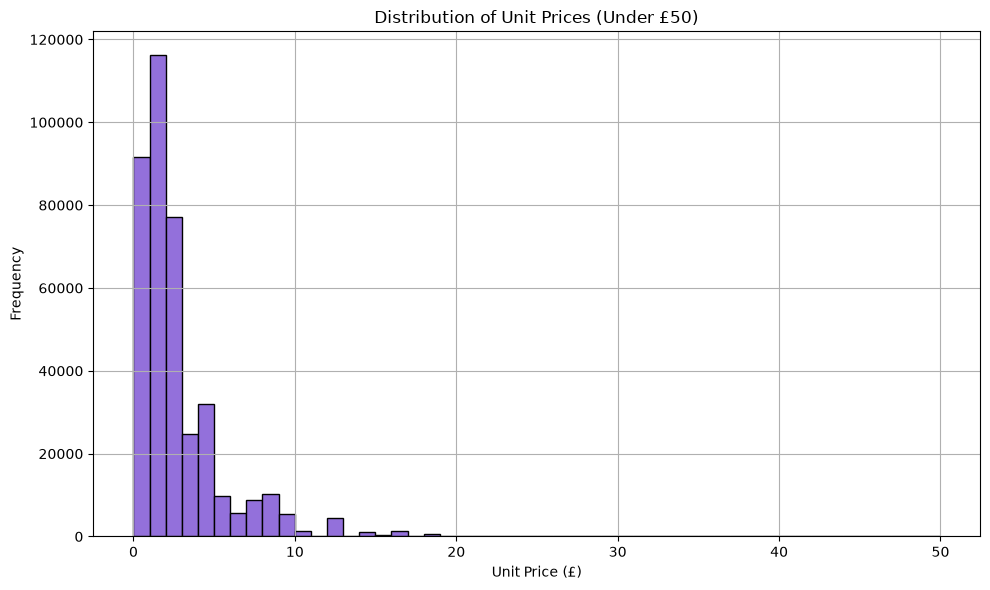

In [121]:
# CHART 4: Distribution of Unit Prices
# We limit to prices under 50 to get a readable view (extreme outliers exist beyond this)
plt.figure(figsize=(10, 6))
df_ecom[df_ecom['unitprice'] < 50]['unitprice'].hist(bins=50, color='mediumpurple', edgecolor='black')

plt.title('Distribution of Unit Prices (Under £50)')
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Finding:** Most products are priced under £5, with the highest concentration between
£1 and £2. This indicates the store primarily sells low-cost items in bulk rather than
premium products.

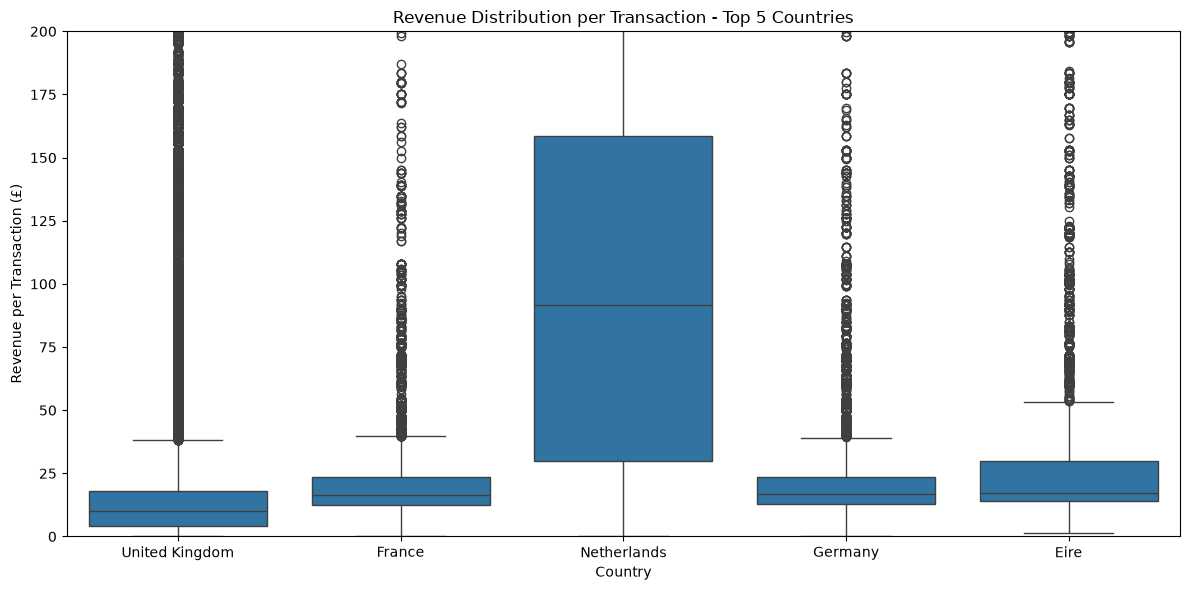

In [122]:
# CHART 5: Revenue Distribution for Top 5 Countries (excluding UK due to scale difference)
top5_countries = top_countries.head(5).index.tolist()
df_top5 = df_ecom[df_ecom['country'].isin(top5_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5, x='country', y='revenue')

plt.title('Revenue Distribution per Transaction - Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Revenue per Transaction (£)')
plt.ylim(0, 200)  # zoom in to see the bulk of the data, ignoring extreme outliers
plt.tight_layout()
plt.show()

## Task 4: Data Visualization (continued)
### Dataset 2 — Netflix Movies & TV Shows

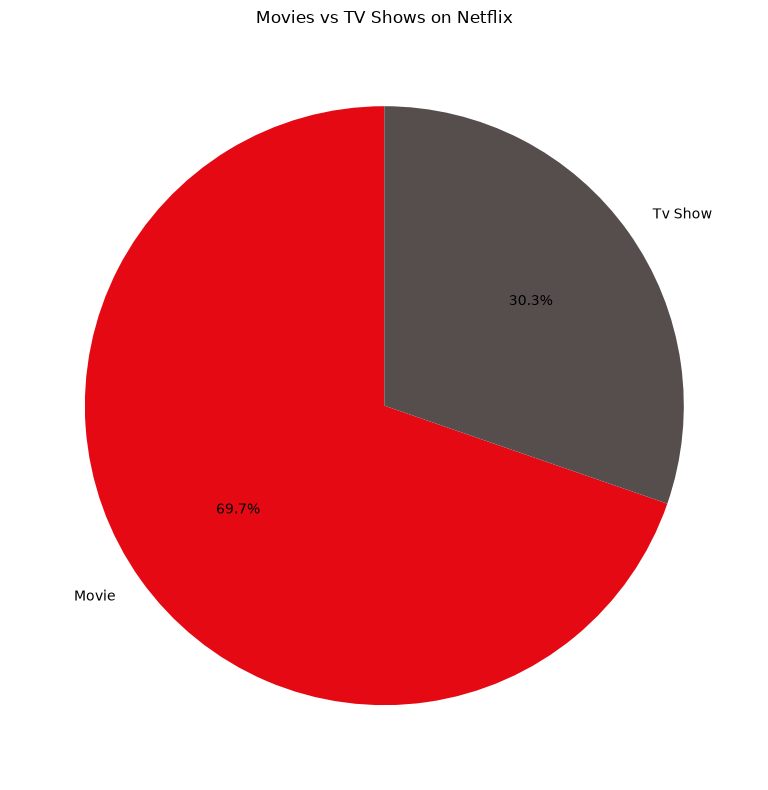

In [123]:
# CHART 1: Movies vs TV Shows Distribution
plt.figure(figsize=(8, 8))
type_distribution.plot(kind='pie', autopct='%1.1f%%', colors=['#E50914', '#564d4d'], startangle=90)

plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('')  # remove default y-label
plt.tight_layout()
plt.show()

**Finding:** Movies make up 69.7% of Netflix's catalog compared to 30.3% for TV Shows —
Netflix's library is more than twice as movie-heavy as it is TV-show-heavy.

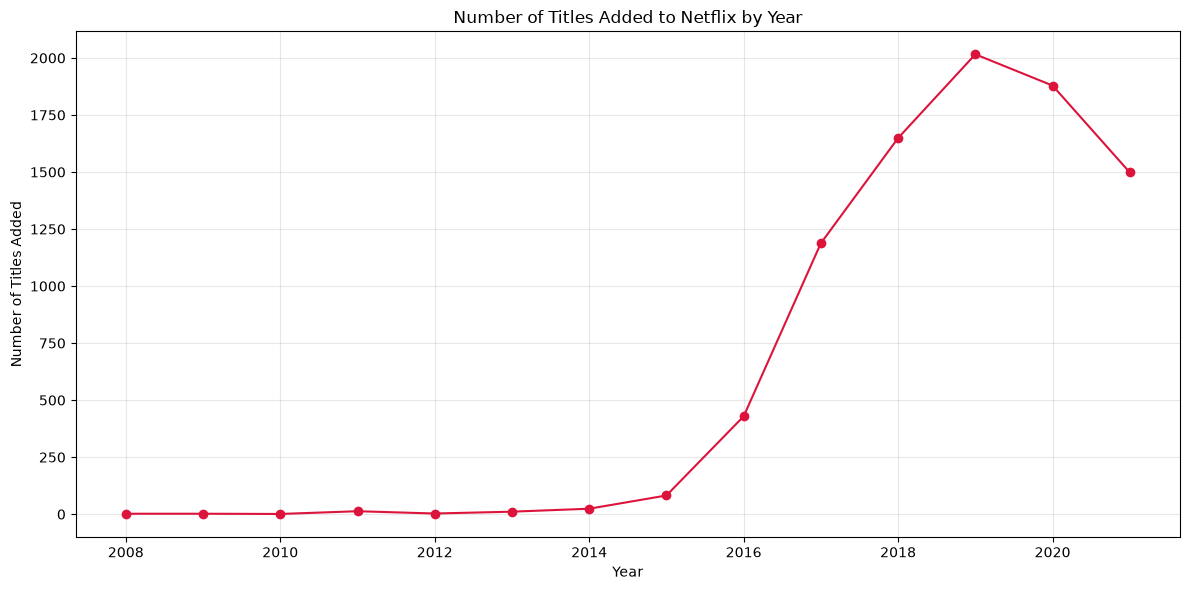

In [124]:
# CHART 2: Content Added by Year
plt.figure(figsize=(12, 6))
content_by_year.plot(kind='line', marker='o', color='crimson')

plt.title('Number of Titles Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Finding:** Content additions grew sharply from 2016 to 2019, peaking at over 2,000
titles in 2019. The decline in 2020-2021 likely reflects both pandemic-related
production delays and the dataset's collection cutoff.

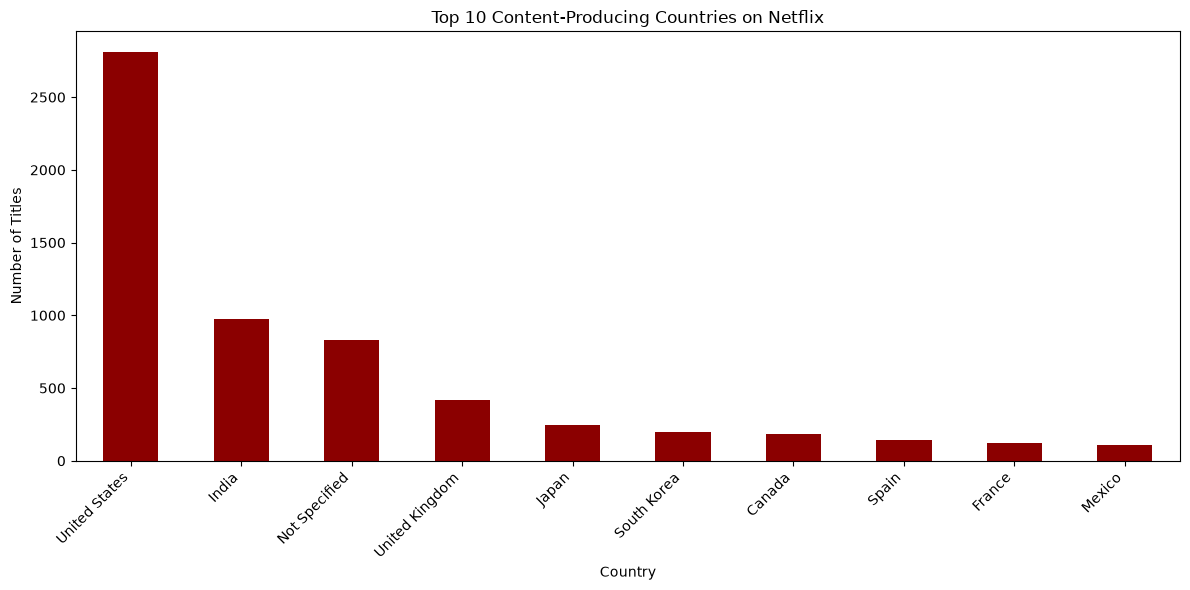

In [125]:
# CHART 3: Top 10 Content-Producing Countries
plt.figure(figsize=(12, 6))
top_countries_netflix.plot(kind='bar', color='darkred')

plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** The United States dominates Netflix's content library with 2,812 titles —
nearly 3 times more than India, the second-largest producer. "Not Specified" ranks third,
representing titles where country data was missing in the original dataset.

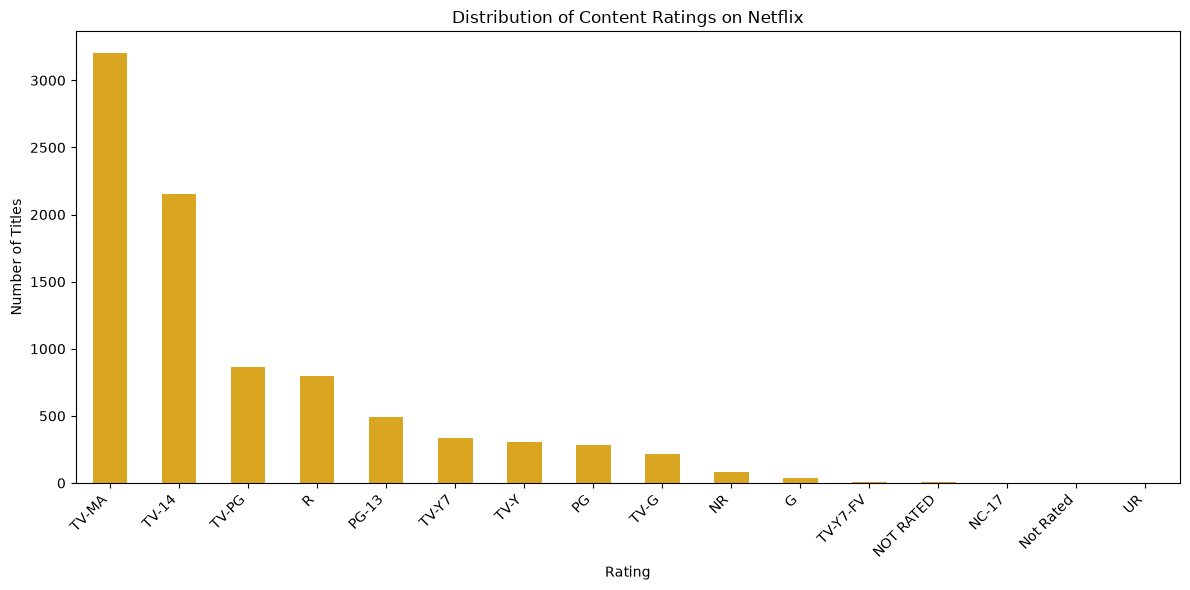

In [126]:
# CHART 4: Most Common Content Ratings
plt.figure(figsize=(12, 6))
rating_counts.plot(kind='bar', color='goldenrod')

plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding:** TV-MA (mature audiences) is the most common rating with 3,205 titles,
followed by TV-14 with 2,157. This suggests Netflix's catalog is skewed toward
content for adult and teen audiences rather than younger viewers.

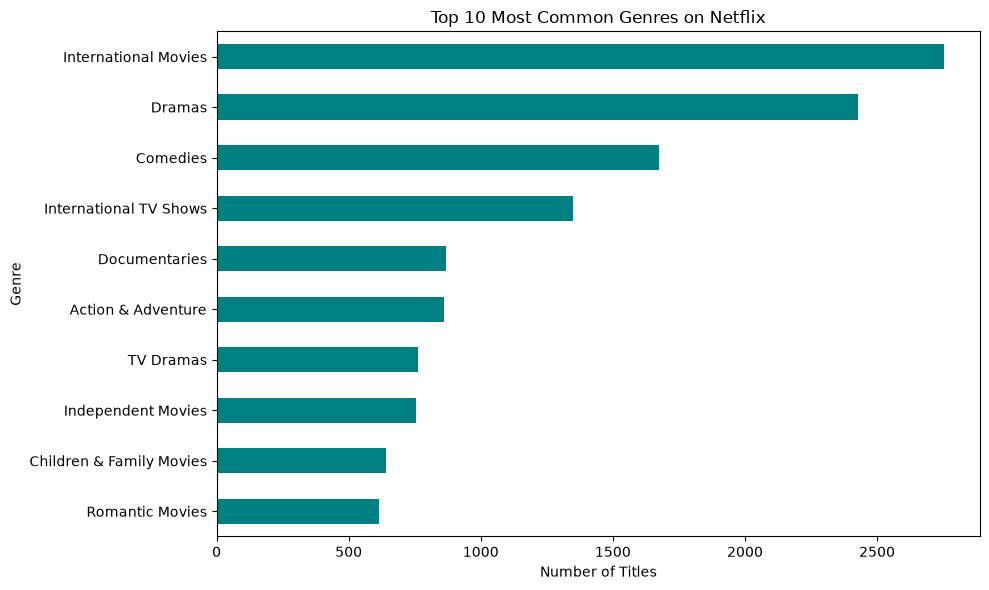

In [127]:
# CHART 5: Top 10 Genres
plt.figure(figsize=(10, 6))
genre_counts.sort_values().plot(kind='barh', color='teal')

plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Finding:** "International Movies" is the most common genre (2,752 titles), followed by
"Dramas" (2,427) and "Comedies" (1,674) — reflecting Netflix's global content strategy
and focus on dramatic storytelling.

## Task 5: Insights
### Dataset 1 — E-commerce Transactions

**1. The business basically runs on a Q4 rush.**
Revenue climbs steadily from August right through to November 2011, hitting its highest
point — over £1.15 million in November. That's a clear sign customers are stocking up
ahead of Christmas. Whoever runs this business probably already feels this every year: stock has to be ready well before November, not during it.

**2. This is, for all intents and purposes, a UK business.**
The UK alone brought in over £7.2 million, which is more than 25 times what the next country (Netherlands) managed. Every other country barely shows up on the chart. That's not necessarily bad, it means there's a loyal local customer base but it also means almost all the eggs are in one basket. If anything disrupted the UK market specifically, the impact would be huge.

**3. The "bestsellers" aren't necessarily the moneymakers.**
"Paper Craft, Little Birdie" and "Medium Ceramic Top Storage Jar" sold over 75,000 units each, way ahead of everything else. But these are cheap items, mostly under £5. So while they look impressive in a "units sold" chart, they're probably not what's actually paying
the bills. The real money likely comes from a different mix of products.

**4. A handful of customers are doing a lot of heavy lifting.**
The top 10 customers brought in anywhere from £77K to £280K each. One customer in particular — 16446 — only placed 2 orders total, but each order averaged over £84,000. That's almost certainly a wholesale buyer, not a regular shopper. Losing a customer like
that would leave a real dent.

**5. Most days are quiet, but every so often there's a big one.**
Looking at the spread of transaction values, most purchases are small; under £50. But scattered throughout are these occasional big outlier orders. So the business has two very different customer types living side by side: everyday small buyers, and occasional bulk buyers who show up rarely but spend a lot when they do.

### Dataset 2 — Netflix Movies & TV Shows

**1. Netflix built its catalog on movies first.**
Roughly 7 out of every 10 titles are movies, not TV shows. Makes sense historically, movies are cheaper and faster to license or produce than building out a whole series, so
it's a logical way to bulk up a catalog early on.

**2. 2016 to 2019 was Netflix's big growth spurt.**
Titles added per year jumped from 429 in 2016 to over 2,000 by 2019; nearly 5x in three years. This lines up exactly with the period everyone remembers Netflix going "global" and pouring money into content. The drop after 2020 is probably a mix of pandemic production delays and just where this dataset's data collection stopped.

**3. The US still leads, but India's presence says a lot.**
The US has nearly 2,800 titles, way more than anywhere else. But India sits in second place with almost 1,000 — a clear signal that Netflix has been actively investing in
local content for big international markets, not just exporting American shows
everywhere.

**4. This catalog is not really built for kids.**
TV-MA and TV-14 together make up over 60% of everything on the platform. Content meant for younger viewers (TV-Y, TV-G, G) is a small slice by comparison. If someone were
picking Netflix purely for family-friendly content, the numbers suggest they'd have slim
pickings.

**5. The catalog leans heavily international and dramatic.**
"International Movies," "Dramas," and "Comedies" are the three biggest genres by far. Nothing region-specific or niche cracks the top of the list — it's all broad, widely
appealing categories, which tracks with a platform trying to serve a global audience rather than one specific country.

## Saving Cleaned Datasets

In [128]:
# Save both cleaned datasets as CSV files
# index=False prevents pandas from adding an extra unnamed column for row numbers

df_ecom.to_csv("cleaned_ecommerce.csv", index=False)
df_netflix.to_csv("cleaned_netflix.csv", index=False)

print("Both cleaned datasets saved successfully!")
print(f"E-commerce: {len(df_ecom)} rows")
print(f"Netflix: {len(df_netflix)} rows")

Both cleaned datasets saved successfully!
E-commerce: 392692 rows
Netflix: 8797 rows
